<a href="https://colab.research.google.com/github/OJB-Quantum/Monte-Carlo-Sim/blob/main/CUDA_Accelerated_Slot_Line_Waveguide_Sim_E_Field.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install cupy-cuda12x vispy  # pick the CUDA variant that matches your runtime

[VisPy] ipynb_webgl backend unavailable → falling back to Matplotlib: Can only select a backend once, already using ['jupyter_rfb'].


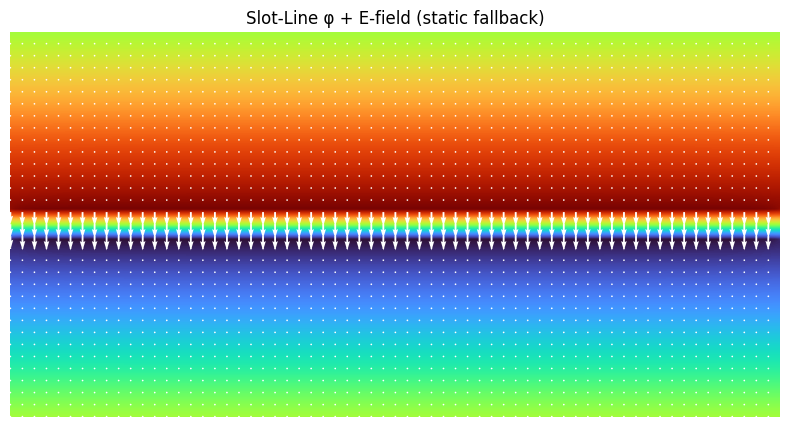

In [8]:
#  GPU Slot‑Line Poisson + WebGL
# -----------------------------------------------------------
# • Works in Colab’s head‑less browser session without Qt.
# • Uses CuPy (CUDA 12 build for L4) + SciPy ≥ 1.13 (array‑API ↦ cuFFT).
# • Renders φ(x,y) + electric‑field arrows via VisPy’s *ipynb_webgl* backend.
# • If WebGL is blocked the script falls back to a Matplotlib static plot
#   (so you always see something).
# -----------------------------------------------------------

# %% — 0) Install/upgrade wheels silently
import subprocess, sys, os

def _pip(*pkgs):
    subprocess.run([sys.executable, "-m", "pip", "install", "--upgrade", "-q", *pkgs], check=False)

_pip("cupy-cuda12x", "scipy>=1.13", "vispy>=0.14", "glfw", "jupyter-rfb")

# %% — 1) Environment & imports
os.environ.setdefault("SCIPY_ARRAY_API", "1")  # must precede SciPy import
import cupy as cp, numpy as np, math
import scipy.fft as _  # noqa: lock‑in array‑API flag

from vispy import app, scene, color  # VisPy ≥ 0.14

# pick a backend compatible with Colab WebGL
try:
    app.use_app("ipynb_webgl")  # pure‑Javascript WebGL, no native OpenGL needed
except Exception as e:
    print("[VisPy] ipynb_webgl backend unavailable → falling back to Matplotlib:", e)
    USE_STATIC = True
else:
    USE_STATIC = False

# %% — 2) geometry: slot‑line cross‑section
Nx, Ny = 1024, 512     # grid
slot_px = 40           # slot width (pixels)
charge   = 1.0         # |line‑charge|

rho = cp.zeros((Ny, Nx), dtype=cp.float32)  # (y,x)
y0 = Ny // 2 - slot_px // 2
y1 = Ny // 2 + slot_px // 2
rho[y0, 1:-1] =  charge
rho[y1, 1:-1] = -charge

# %% — 3) FFT‑based Poisson (periodic BCs)
ky = cp.fft.fftfreq(Ny)[:, None]
kx = cp.fft.fftfreq(Nx)[None, :]
k2 = kx**2 + ky**2
k2[0, 0] = 1.0
phi = cp.real(cp.fft.ifft2(cp.fft.fft2(rho) / (-4 * cp.pi**2 * k2)))

# electric field (GPU)
Ey, Ex = cp.gradient(-phi)

# host copies (float32 for WebGL)
phi_h = cp.asnumpy(phi).astype(np.float32)
Ex_h  = cp.asnumpy(Ex).astype(np.float32)
Ey_h  = cp.asnumpy(Ey).astype(np.float32)

if USE_STATIC:
    # ------------------------------------------------------------------
    # Fallback static plot with Matplotlib (always available in Colab)
    # ------------------------------------------------------------------
    import matplotlib.pyplot as plt

    step = 16
    Y, X = np.mgrid[0:Ny:step, 0:Nx:step]
    plt.figure(figsize=(10,5))
    plt.imshow(phi_h, cmap="turbo", origin="lower")
    plt.quiver(X, Y, Ex_h[::step, ::step], Ey_h[::step, ::step], color="white", scale=50)
    plt.title("Slot‑Line φ + E‑field (static fallback)")
    plt.axis("off")
    plt.show()
else:
    # ------------------------------------------------------------------
    # WebGL interactive visual
    # ------------------------------------------------------------------
    step = 16  # arrow spacing
    ys, xs = np.mgrid[0:Ny:step, 0:Nx:step]
    pos    = np.c_[xs.ravel(), ys.ravel()]
    vecs   = np.c_[Ex_h[::step, ::step].ravel(), Ey_h[::step, ::step].ravel()]

    # normalise arrows for display length
    norm   = np.linalg.norm(vecs, axis=1, keepdims=True) + 1e-9
    vecs_u = vecs / norm

    canvas = scene.SceneCanvas(keys="interactive", bgcolor="black", size=(900,450), show=True)
    view   = canvas.central_widget.add_view()
    view.camera = scene.PanZoomCamera(aspect=Nx/Ny)

    # potential image
    scene.visuals.Image(phi_h, cmap="turbo", parent=view.scene,
                        method="subdivide", clim=(phi_h.min(), phi_h.max()))

    # flip y to keep origin bottom‑left
    view.scene.transform = scene.transforms.STTransform(scale=(1, -1), translate=(0, Ny))

    # E‑field arrows (white)
    scene.visuals.Arrow(pos=pos, arrows=vecs_u, color="white", width=2,
                        arrow_size=8, parent=view.scene)

    view.camera.set_range()
    canvas.title = "Slot‑Line Waveguide : φ + E‑field (GPU, WebGL)"

    canvas  # return to notebook

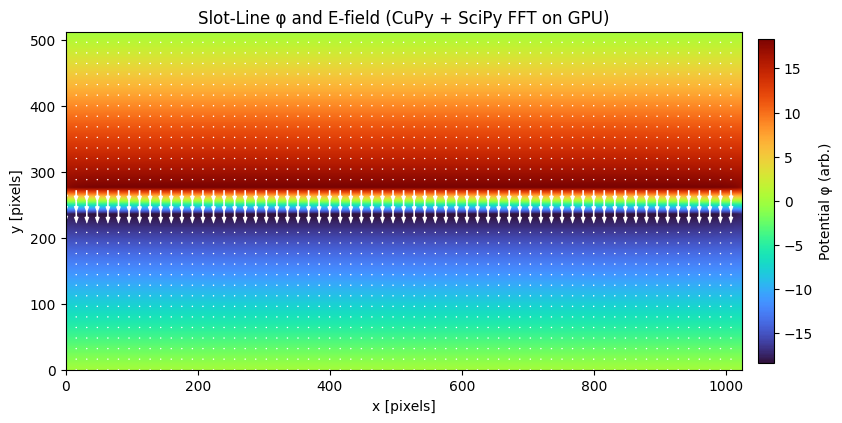

In [17]:
#  GPU Slot-Line Poisson  + Matplotlib display
# ---------------------------------------------------------------
#  • Heavy lifting still on GPU (CuPy  +  SciPy-Array-API → cuFFT).
#  • Robust in Colab – no OpenGL, no VisPy, no framebuffer errors.
#  • Turn on ipympl for pan/zoom if you prefer:
#        pip install ipympl && from google.colab import output;
#        output.enable_custom_widget_manager()
#        %matplotlib widget
# ---------------------------------------------------------------

# --- 0) Quiet runtime install ----------------------------------
import subprocess, sys, os, math, numpy as np
def _pip(pkgs): subprocess.run(
        [sys.executable, "-m", "pip", "-q", "install", "--upgrade", *pkgs.split()],
        check=False)

_pip("cupy-cuda12x")
_pip("scipy>=1.13")

# Optional: uncomment next two lines for an interactive Matplotlib widget
# _pip("ipympl")
# from google.colab import output; output.enable_custom_widget_manager()

# --- 1) Imports & SciPy Array-API flag --------------------------
import cupy as cp
os.environ.setdefault("SCIPY_ARRAY_API", "1")
import scipy.fft as sp_fft      # noqa: F401  (activates flag)

import matplotlib.pyplot as plt
# %matplotlib widget   # <-- uncomment if ipympl installed

# --- 2) Geometry -----------------------------------------------
Nx, Ny, slot_w = 1024, 512, 40
rho = cp.zeros((Ny, Nx), dtype=cp.float32)
cy  = Ny // 2
rho[cy - slot_w//2, 1:-1] =  1.0    # +q line
rho[cy + slot_w//2, 1:-1] = -1.0    # –q line

# --- 3) Poisson solve (GPU) ------------------------------------
ky = cp.fft.fftfreq(Ny)[:, None]
kx = cp.fft.fftfreq(Nx)[None, :]
k2 = kx**2 + ky**2
k2[0, 0] = 1.0                      # avoid /0
phi = cp.real(cp.fft.ifft2(cp.fft.fft2(rho) / (-4*cp.pi**2*k2)))

Ey, Ex = cp.gradient(-phi)

# --- 4) Copy to host (tiny) ------------------------------------
phi_h = cp.asnumpy(phi)
Ex_h  = cp.asnumpy(Ex)
Ey_h  = cp.asnumpy(Ey)

# --- 5) Plot with Matplotlib -----------------------------------
fig, ax = plt.subplots(figsize=(9, 4.5))
im = ax.imshow(phi_h, cmap="turbo", origin="lower",
               extent=[0, Nx, 0, Ny])
ax.set_title("Slot-Line φ and E-field (CuPy + SciPy FFT on GPU)")
ax.set_xlabel("x [pixels]"); ax.set_ylabel("y [pixels]")

# Down-sample arrows so the quiver isn’t too dense
step = 16
xs, ys = np.meshgrid(np.arange(0, Nx, step),
                     np.arange(0, Ny, step))
ax.quiver(xs, ys,
          Ex_h[::step, ::step], Ey_h[::step, ::step],
          color="white", scale=50, headwidth=3, headlength=4)

# Add colour-bar for φ
cbar = fig.colorbar(im, ax=ax, shrink=0.8, pad=0.02)
cbar.set_label("Potential φ (arb.)")

plt.tight_layout()
plt.show()

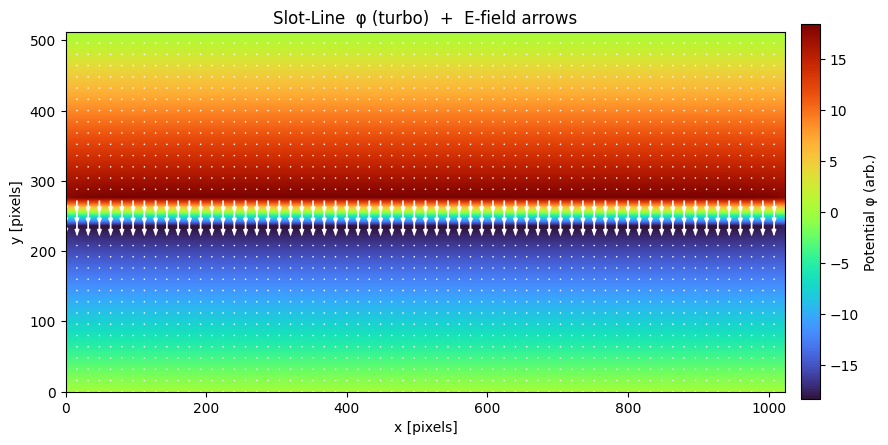

In [19]:
# GPU Slot-Line Poisson  + Matplotlib display
# -------------------------------------------------------------
# heavy numerics on GPU (CuPy + cuFFT) – visualization via
# cp.asnumpy → Matplotlib (works everywhere, no OpenGL)
# -------------------------------------------------------------

# 0) Quiet installs (≈5 s)
import subprocess, sys, os, numpy as np
def _pip(pkgs): subprocess.run(
        [sys.executable, "-m", "pip", "-q", "install", "--upgrade", *pkgs.split()],
        check=False)

_pip("cupy-cuda12x")    # CUDA-12 build for Colab’s L4 GPU
_pip("scipy>=1.13")

# 1) Imports  &  SciPy-Array-API switch
import cupy as cp
os.environ.setdefault("SCIPY_ARRAY_API", "1")   # ⇐ enables cuFFT dispatch
import scipy.fft as sp_fft   # noqa: F401  (flag takes effect here)

import matplotlib.pyplot as plt
plt.rcParams.update({"image.cmap": "turbo"})

# 2) Slot-line geometry (charge lines ±q)
Nx, Ny, slot_px = 1024, 512, 40
rho = cp.zeros((Ny, Nx), dtype=cp.float32)      # ρ(y,x) on GPU
cy  = Ny // 2
rho[cy - slot_px // 2, 1:-1] =  1.0             # +q line
rho[cy + slot_px // 2, 1:-1] = -1.0             # –q line

# 3) FFT-based Poisson solve (periodic BCs)
ky = cp.fft.fftfreq(Ny)[:, None]
kx = cp.fft.fftfreq(Nx)[None, :]
k2 = kx**2 + ky**2
k2[0, 0] = 1.0                                  # avoid /0 at k=0
phi = cp.real(cp.fft.ifft2(cp.fft.fft2(rho) / (-4 * cp.pi**2 * k2)))

# Electric field  E = −∇φ
Ey, Ex = cp.gradient(-phi)

# 4) Copy to host for plotting
phi_h = cp.asnumpy(phi)                         # (Ny, Nx) float32
Ex_h  = cp.asnumpy(Ex)
Ey_h  = cp.asnumpy(Ey)

# 5) Matplotlib visualization
fig, ax = plt.subplots(figsize=(9, 4.5))
im = ax.imshow(phi_h, origin="lower",
               extent=[0, Nx, 0, Ny])
ax.set_title("Slot-Line  φ (turbo)  +  E-field arrows")
ax.set_xlabel("x [pixels]"); ax.set_ylabel("y [pixels]")

# Down-sample arrows for clarity
step = 16
xs, ys = np.meshgrid(np.arange(0, Nx, step),
                     np.arange(0, Ny, step))
ax.quiver(xs, ys,
          Ex_h[::step, ::step], Ey_h[::step, ::step],
          color="white", scale=50, headwidth=3, headlength=4)

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.02, label="Potential φ (arb.)")
plt.tight_layout(); plt.show()